In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from pickle import load
from pathlib import Path

import re
from tqdm import tqdm

import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    # Use LaTeX
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Lines
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 1,

    # Ticks
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # Save figures
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

In [28]:
ROOT = Path.cwd()
if not (ROOT / 'data' / 'single_dot_error.pickle').exists() and (ROOT / 'charge_stability' / 'data' / 'single_dot_error.pickle').exists():
    ROOT = ROOT / 'charge_stability'

DATA_PATH = ROOT / 'data'
FIGURE_PATH = ROOT / 'Figures'
FIGURE_PATH.mkdir(exist_ok=True)

RESULTS_FILE = DATA_PATH / 'single_dot_error.pickle'
with RESULTS_FILE.open('rb') as f:
    single_dot_error_results = load(f)

single_dot_error_results['metadata']

{'description': 'Closed-shell charge stability sweep for a double quantum dot.',
 'length_scale_nm': 50.0,
 'effective_units_reference_energy': 2.5702165936004097e-23,
 'coulomb_energy_effective_units': 15.34392984483895,
 'eV_error_tolerance': 1e-07,
 'e_conv_tolerance_effective_units': 0.0006233624971487868,
 'log_file': 'data/single_dot_error.log'}

# Time Analysis of Single Dot Results

In [29]:
records = []

for run in single_dot_error_results['runs']:
    n_electrons = run['n_electrons']
    run_voltage = run.get('V')

    for point in run['points']:
        row = {key: value for key, value in point.items() if key != 'profiler'}
        row['N'] = n_electrons
        row['run_v'] = run_voltage if run_voltage is not None else point.get('v')
        row['profiler'] = point['profiler']
        records.append(row)

results_df = (
    pd.DataFrame(records)
    .sort_values(['N', 'n_orbitals'])
    .reset_index(drop=True)
)

results_df[['N', 'run_v', 'n_orbitals', 'energy', 'n_iterations', 'converged', 'log_time']]

,N,run_v,n_orbitals,energy,n_iterations,converged,log_time
0,2,0.4,2,-44.915651,5,True,3.406208
1,2,0.4,4,-58.883493,13,True,52.541389
2,2,0.4,6,-58.908404,3,True,43.665321
3,2,0.4,8,-58.931016,3,True,82.137367
4,2,0.4,10,-58.934836,3,True,87.121484
5,2,0.4,12,-58.945949,3,True,276.554473
6,2,0.4,14,-58.948053,3,True,466.874746
7,2,0.4,16,-58.948490,3,True,724.715429
8,3,0.6,3,-93.190384,7,True,21.212392
9,3,0.6,5,-100.828934,30,True,523.802154


In [31]:
def profile_stage_info(stage_name):
    iteration = None

    match = re.search(r'for iteration (\d+)$', stage_name)
    if match is None:
        iterative_prefixes = (
            'Integrals ',
            'FCI ',
            'Orbital Refinement ',
            'Two-body integrals transformation ',
            'RDM2 transformation ',
        )
        if stage_name.startswith(iterative_prefixes):
            match = re.search(r'(\d+)$', stage_name)

    if match is not None:
        iteration = int(match.group(1))

    if stage_name == 'MAD world initialization':
        stage = 'MAD world initialization'
    elif stage_name in {'MRA potential creation', 'MRA function factory initialization'}:
        stage = 'MRA potential creation'
    elif stage_name == 'Single-particle orbitals calculation':
        stage = 'Single-particle orbitals'
    elif stage_name == 'Integral computation':
        stage = 'Initial integral setup'
    elif stage_name == 'Two-body integrals computation':
        stage = 'Two-body integral setup'
    elif stage_name.startswith('Integrals computation for iteration') or stage_name.startswith('Integrals '):
        stage = 'SCF integrals'
    elif stage_name.startswith('FCI calculation for iteration') or stage_name.startswith('FCI '):
        stage = 'FCI'
    elif stage_name.startswith('Two-body integrals transformation'):
        stage = 'Two-body transform'
    elif stage_name.startswith('RDM2 transformation'):
        stage = 'RDM2 transform'
    elif stage_name.startswith('Orbital Refinement for iteration') or stage_name.startswith('Orbital Refinement '):
        stage = 'Orbital refinement'
    else:
        stage = stage_name

    phase = 'SCF iteration' if iteration is not None else 'Setup'
    return stage, iteration, phase


profile_records = []

for _, row in results_df.iterrows():
    for stage_name, metrics in row['profiler'].items():
        stage, iteration, phase = profile_stage_info(stage_name)
        profile_records.append({
            'N': row['N'],
            'v': row['run_v'],
            'n_orbitals': row['n_orbitals'],
            'iteration': iteration,
            'phase': phase,
            'stage': stage,
            'raw_stage': stage_name,
            'time_s': metrics['time_s'],
            'memory_change_MB': metrics['memory_change_MB'],
        })

profile_df = pd.DataFrame(profile_records)

time_by_stage = (
    profile_df
    .groupby(['N', 'v', 'n_orbitals', 'phase', 'stage'], as_index=False, dropna=False)
    .agg(time_s=('time_s', 'sum'), memory_change_MB=('memory_change_MB', 'sum'))
)

stage_order = [
    'MAD world initialization',
    'MRA potential creation',
    'Single-particle orbitals',
    'Initial integral setup',
    'Two-body integral setup',
    'SCF integrals',
    'Two-body transform',
    'FCI',
    'RDM2 transform',
    'Orbital refinement',
]

stage_order = [stage for stage in stage_order if stage in time_by_stage['stage'].unique()]
stage_colors = dict(zip(stage_order, sns.color_palette('tab10', n_colors=len(stage_order))))

time_by_stage.head()

,N,v,n_orbitals,stage,time_s,memory_change_MB
0,2,0.4,2,FCI,0.399891,1.574219
1,2,0.4,2,MAD world initialization,0.307171,25.750000
2,2,0.4,2,MRA potential creation,2.172386,4.140625
3,2,0.4,2,Orbital refinement,2.655987,0.085938
4,2,0.4,2,SCF integrals,0.348645,0.128906
...,...,...,...,...,...,...
133,3,0.6,19,RDM2 transform,0.001618,0.000000
134,3,0.6,19,SCF integrals,247.886503,949.824219
135,3,0.6,19,Single-particle orbitals,28.984888,-51.027344
136,3,0.6,19,Two-body integral setup,0.000018,0.000000


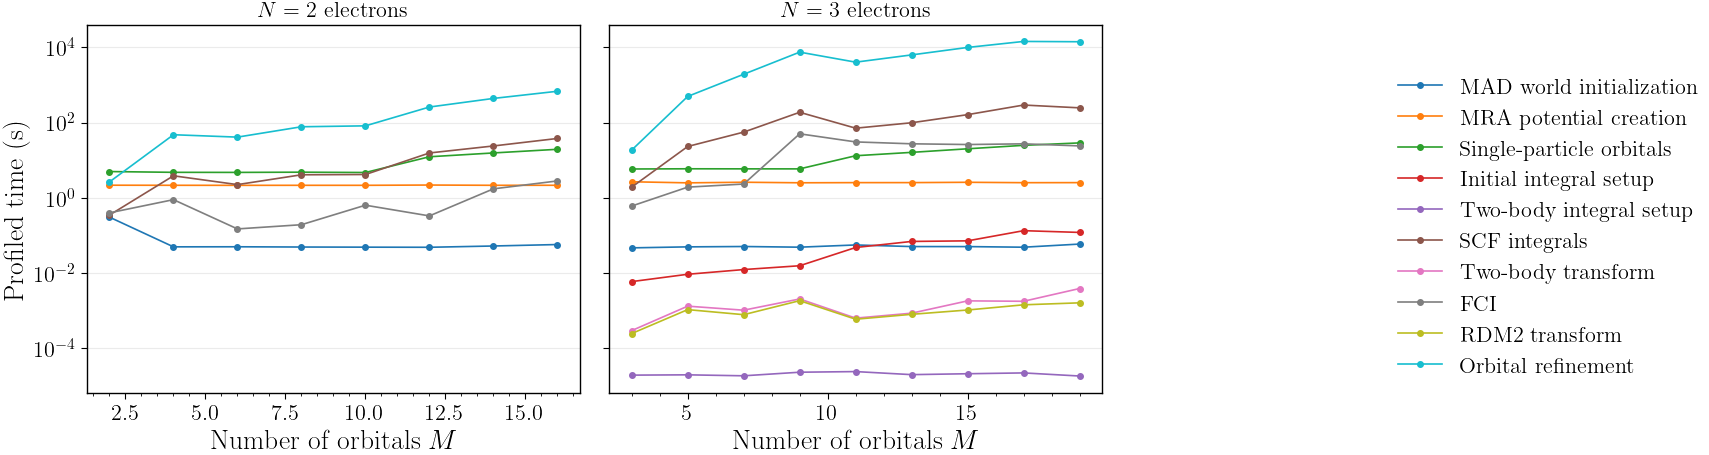

In [32]:
stage_order = [
    'MAD world initialization',
    'MRA potential creation',
    'Single-particle orbitals',
    'Initial integral setup',
    'Two-body integral setup',
    'SCF integrals',
    'Two-body transform',
    'FCI',
    'RDM2 transform',
    'Orbital refinement',
]

stage_order = [stage for stage in stage_order if stage in time_by_stage['stage'].unique()]
stage_colors = dict(zip(stage_order, sns.color_palette('tab10', n_colors=len(stage_order))))

n_values = sorted(time_by_stage['N'].unique())
fig, axes = plt.subplots(1, len(n_values), figsize=(7 * len(n_values), 5), sharey=True)
if len(n_values) == 1:
    axes = [axes]

for ax, n_electrons in zip(axes, n_values):
    data_n = time_by_stage[time_by_stage['N'] == n_electrons]

    for stage in stage_order:
        stage_data = data_n[data_n['stage'] == stage].sort_values('n_orbitals')
        if stage_data.empty:
            continue

        ax.plot(
            stage_data['n_orbitals'],
            stage_data['time_s'],
            marker='o',
            label=stage,
            color=stage_colors[stage],
        )

    ax.set_title(f'$N={n_electrons}$ electrons')
    ax.set_xlabel('Number of orbitals $M$')
    ax.set_yscale('log')
    ax.grid(True, which='both', axis='y', alpha=0.25)

axes[0].set_ylabel('Profiled time (s)')

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout(rect=(0, 0, 0.82, 1))

fig.savefig(FIGURE_PATH / 'single_dot_time_profile.pdf', dpi=600)
fig.savefig(FIGURE_PATH / 'single_dot_time_profile.png', dpi=300)
plt.show()

## Per-Iteration Timing Statistics

In [ ]:
iteration_time_by_stage = (
    profile_df[profile_df['iteration'].notna()]
    .assign(iteration=lambda df: df['iteration'].astype(int))
    .groupby(['N', 'v', 'n_orbitals', 'iteration', 'stage'], as_index=False)
    .agg(time_s=('time_s', 'sum'), memory_change_MB=('memory_change_MB', 'sum'))
)

iteration_time_table = (
    iteration_time_by_stage
    .pivot_table(
        index=['N', 'v', 'n_orbitals', 'iteration'],
        columns='stage',
        values='time_s',
        aggfunc='sum',
        fill_value=0.0,
    )
    .reset_index()
)

stage_columns = [col for col in iteration_time_table.columns if col not in {'N', 'v', 'n_orbitals', 'iteration'}]
iteration_time_table['total_iteration_time_s'] = iteration_time_table[stage_columns].sum(axis=1)
iteration_time_table = iteration_time_table.sort_values(['N', 'n_orbitals', 'iteration']).reset_index(drop=True)

iteration_time_table.head(20)

In [ ]:
def summarize_iteration_times(df, group_cols):
    stats = (
        df
        .groupby(group_cols, as_index=False)
        .agg(
            n_iteration_samples=('time_s', 'count'),
            total_time_s=('time_s', 'sum'),
            mean_time_s=('time_s', 'mean'),
            median_time_s=('time_s', 'median'),
            std_time_s=('time_s', 'std'),
            min_time_s=('time_s', 'min'),
            q25_time_s=('time_s', lambda values: values.quantile(0.25)),
            q75_time_s=('time_s', lambda values: values.quantile(0.75)),
            max_time_s=('time_s', 'max'),
        )
    )
    stats['std_time_s'] = stats['std_time_s'].fillna(0.0)
    stats['iqr_time_s'] = stats['q75_time_s'] - stats['q25_time_s']
    return stats


iteration_stage_stats_by_orbital = summarize_iteration_times(
    iteration_time_by_stage,
    ['N', 'n_orbitals', 'stage'],
)

iteration_stage_stats = summarize_iteration_times(
    iteration_time_by_stage,
    ['N', 'stage'],
)

iteration_stage_stats

In [ ]:
iteration_stage_order = [stage for stage in stage_order if stage in iteration_time_by_stage['stage'].unique()]

n_values = sorted(iteration_time_by_stage['N'].unique())
fig, axes = plt.subplots(1, len(n_values), figsize=(7 * len(n_values), 5), sharey=True)
if len(n_values) == 1:
    axes = [axes]

for ax, n_electrons in zip(axes, n_values):
    data_n = iteration_time_by_stage[iteration_time_by_stage['N'] == n_electrons]

    sns.boxplot(
        data=data_n,
        x='stage',
        y='time_s',
        order=iteration_stage_order,
        palette=stage_colors,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=data_n,
        x='stage',
        y='time_s',
        order=iteration_stage_order,
        color='black',
        size=2.5,
        alpha=0.35,
        jitter=0.2,
        ax=ax,
    )

    ax.set_title(f'$N={n_electrons}$ electrons')
    ax.set_xlabel('SCF iteration stage')
    ax.set_yscale('log')
    ax.grid(True, which='both', axis='y', alpha=0.25)
    ax.tick_params(axis='x', rotation=35)

axes[0].set_ylabel('Time per iteration stage (s)')
fig.tight_layout()

fig.savefig(FIGURE_PATH / 'single_dot_iteration_stage_time_statistics.pdf', dpi=600)
fig.savefig(FIGURE_PATH / 'single_dot_iteration_stage_time_statistics.png', dpi=300)
plt.show()

In [ ]:
n_values = sorted(iteration_time_by_stage['N'].unique())
fig, axes = plt.subplots(1, len(n_values), figsize=(7 * len(n_values), 5), sharey=True)
if len(n_values) == 1:
    axes = [axes]

for ax, n_electrons in zip(axes, n_values):
    data_n = iteration_stage_stats_by_orbital[iteration_stage_stats_by_orbital['N'] == n_electrons]

    for stage in iteration_stage_order:
        stage_data = data_n[data_n['stage'] == stage].sort_values('n_orbitals')
        if stage_data.empty:
            continue

        lower_error = stage_data['median_time_s'] - stage_data['q25_time_s']
        upper_error = stage_data['q75_time_s'] - stage_data['median_time_s']

        ax.errorbar(
            stage_data['n_orbitals'],
            stage_data['median_time_s'],
            yerr=[lower_error, upper_error],
            marker='o',
            capsize=3,
            label=stage,
            color=stage_colors[stage],
        )

    ax.set_title(f'$N={n_electrons}$ electrons')
    ax.set_xlabel('Number of orbitals $M$')
    ax.set_yscale('log')
    ax.grid(True, which='both', axis='y', alpha=0.25)

axes[0].set_ylabel('Median time per iteration stage (s)')
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout(rect=(0, 0, 0.82, 1))

fig.savefig(FIGURE_PATH / 'single_dot_iteration_stage_median_scaling.pdf', dpi=600)
fig.savefig(FIGURE_PATH / 'single_dot_iteration_stage_median_scaling.png', dpi=300)
plt.show()